In [6]:
import pandas as pd, numpy as np, os, sys, warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [17]:
df = pd.read_csv('data/fit_frenchie_trades_attributes_freq.csv')
trades = pd.read_csv('data/fit_frenchie_trades.csv')

features = ['Accessories', 'Background', 'Body', 'Eyes', 'Hat', 'Mouth']
for col in features:
    df[col] = df[col].astype(str)

df

,nft_id,trade_price,floor_price,Accessories,Background,Body,Eyes,Hat,Mouth,Accessories_Background_freq,Accessories_Body_freq,Accessories_Eyes_freq,Accessories_Hat_freq,Accessories_Mouth_freq,Background_Body_freq,Background_Eyes_freq,Background_Hat_freq,Background_Mouth_freq,Body_Eyes_freq,Body_Hat_freq,Body_Mouth_freq,Eyes_Hat_freq,Eyes_Mouth_freq,Hat_Mouth_freq,Mouth_freq,Accessories_freq,Background_freq,Body_freq,Eyes_freq,Hat_freq
0,1088,4.00,4.00,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147
1,1088,5.16,5.16,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147
2,1088,8.15,8.15,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147
3,1088,4.14,4.14,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147
4,1065,4.00,4.00,nan,Spiced Orange,Tan,White Shades,Headphones,Toothy,0.0527,0.0660,0.0660,0.0220,0.0740,0.0207,0.0147,0.0053,0.0200,0.0207,0.0087,0.0320,0.0087,0.0300,0.0087,0.1853,0.4247,0.1180,0.1553,0.1480,0.0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,36,1.51,0.95,Wings,Lavender Dusk Purple,Tan,Laser Eyes,No Hat,Sad,0.0013,0.0033,0.0013,0.0040,0.0027,0.0180,0.0033,0.0367,0.0147,0.0027,0.0480,0.0167,0.0060,0.0013,0.0387,0.1180,0.0193,0.1187,0.1553,0.0167,0.3147
1996,1028,0.94,0.94,Red Bandana,Forest Moss Green,Black - Overweight,Red Round Shades,Cylinder,Toothy,0.0167,0.0180,0.0060,0.0067,0.0133,0.0260,0.0067,0.0100,0.0253,0.0100,0.0067,0.0373,0.0060,0.0127,0.0107,0.1853,0.0920,0.1247,0.1773,0.0587,0.0493
1997,59,0.94,0.94,nan,Sunlit Gold,Tan,Drowsy,Party Hat,Drooling,0.0673,0.0660,0.0233,0.0247,0.0320,0.0267,0.0047,0.0080,0.0107,0.0080,0.0060,0.0080,0.0027,0.0053,0.0040,0.0700,0.4247,0.1500,0.1553,0.0407,0.0500
1998,614,0.91,0.91,Neck Tattoo,Lavender Dusk Purple,Black,White Round Shades,Slickback,Toothy,0.0047,0.0087,0.0040,0.0027,0.0027,0.0300,0.0100,0.0060,0.0220,0.0240,0.0147,0.0347,0.0033,0.0147,0.0107,0.1853,0.0300,0.1187,0.2333,0.0987,0.0493


In [14]:
# correlation between trade_price and floor_price
prices_col = ['floor_price', 'trade_price']
correlation_floor_trade = df[prices_col].corr()['floor_price']['trade_price']
print(f'Correlation between trade_price and floor_price: {correlation_floor_trade:.2%}')

Correlation between trade_price and floor_price: 53.41%


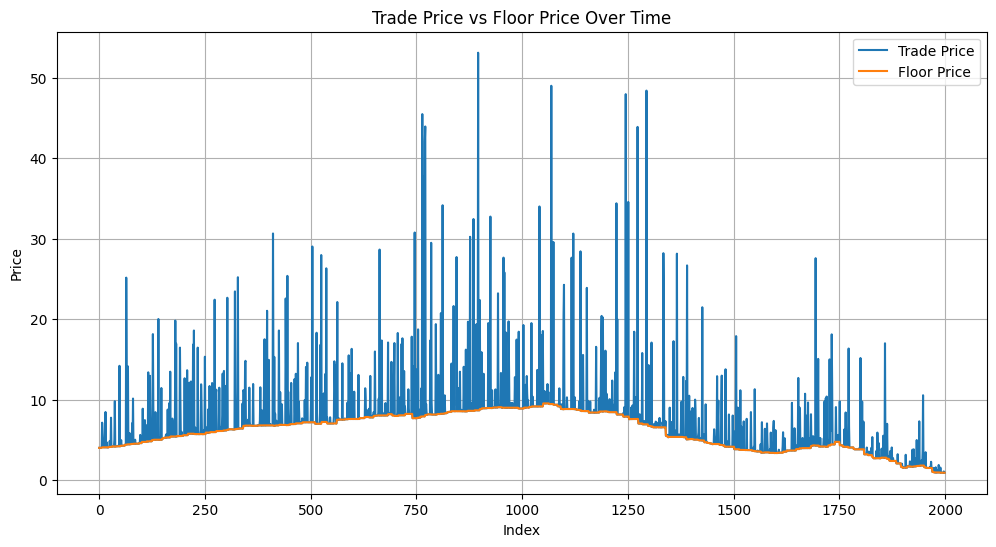

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6), dpi=100)

plt.plot(trades['trade_price'], label='Trade Price')
plt.plot(trades['floor_price'], label='Floor Price')

plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Trade Price vs Floor Price Over Time')
plt.legend()
plt.grid(True)
plt.savefig('img/trade_price_vs_floor_price.png')

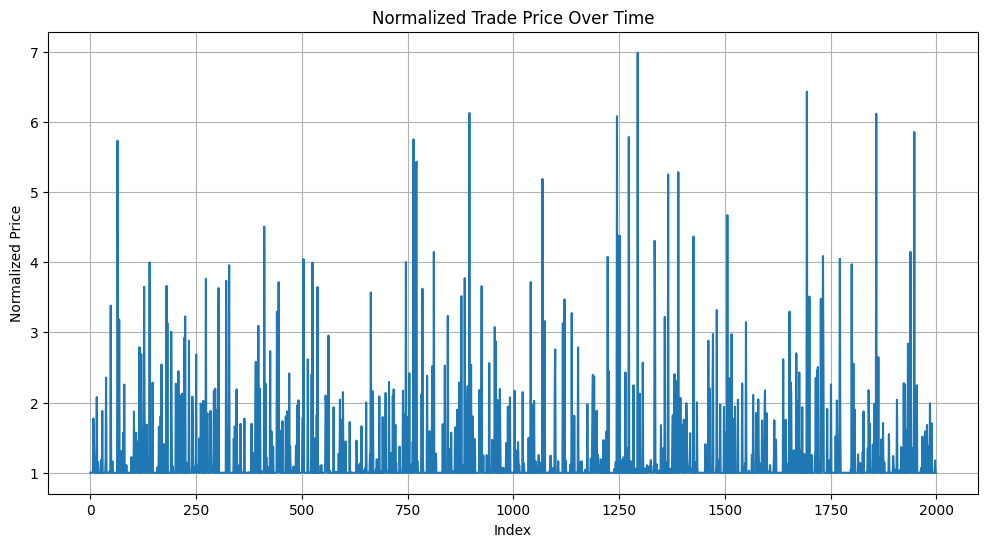

In [34]:
trades['normalized_trade_price'] = trades['trade_price'] / trades['floor_price']
df['normalized_trade_price'] = df['trade_price'] / df['floor_price']

plt.figure(figsize=(12, 6), dpi=100)

trades['normalized_trade_price'].plot()
plt.title('Normalized Trade Price Over Time')
plt.xlabel('Index')
plt.ylabel('Normalized Price')
plt.grid(True)
plt.show()

In [44]:
# can you add categorical encoding for the feature in df in the feature list

data = pd.get_dummies(df, columns=features)

In [47]:
data

,nft_id,trade_price,floor_price,Accessories_Background_freq,Accessories_Body_freq,Accessories_Eyes_freq,Accessories_Hat_freq,Accessories_Mouth_freq,Background_Body_freq,Background_Eyes_freq,Background_Hat_freq,Background_Mouth_freq,Body_Eyes_freq,Body_Hat_freq,Body_Mouth_freq,Eyes_Hat_freq,Eyes_Mouth_freq,Hat_Mouth_freq,Mouth_freq,Accessories_freq,Background_freq,Body_freq,Eyes_freq,Hat_freq,normalized_trade_price,Accessories_Bow Tie,Accessories_Cape,Accessories_Earrings,Accessories_Gold Chain,Accessories_Neck Tattoo,Accessories_Red Bandana,Accessories_Samurai Sword,Accessories_Scarf,Accessories_Sickle,Accessories_Tie,Accessories_Wings,Accessories_nan,Background_Forest Moss Green,Background_Lavender Dusk Purple,Background_Midnight Sapphire Blue,Background_Outer Space,"Background_Red, White, and Blue",Background_Rose Quartz Pink,Background_Seashell Pink,Background_Spiced Orange,Background_Stormcloud Grey,Background_Sunlit Gold,Body_Black,Body_Black - Overweight,Body_Blue,Body_Chocolate,Body_Cream,Body_Lilac,Body_Sable,Body_Tan,Body_Tan - Overweight,Body_White,Body_Zombie,Eyes_3-D Glasses,Eyes_Concerned,Eyes_Cyclop,Eyes_Drowsy,Eyes_Drowsy Cyclop,Eyes_Drowsy Laser Eyes,Eyes_Eye Patch,Eyes_Goggles,Eyes_Gold Shades,Eyes_Laser Eyes,Eyes_Normal,Eyes_Nouns Glasses,Eyes_Red Round Shades,Eyes_Red Shades,Eyes_VR Headset,Eyes_White Round Shades,Eyes_White Shades,Hat_Afro,Hat_Angel Halo,Hat_Baseball Cap,Hat_Beret,Hat_Bone,Hat_Cowboy,Hat_Cylinder,Hat_Devil Horns,Hat_Dreads,Hat_Elvis,Hat_Fire,Hat_Headband,Hat_Headphones,Hat_Leprechaun,Hat_Napoleon,Hat_No Hat,Hat_Party Hat,Hat_Pirate,Hat_Slickback,Hat_Sobrero,Hat_Top Hat,Hat_Wizard,Mouth_Bubble Gum,Mouth_Drooling,Mouth_Feral,Mouth_Happy,Mouth_Mustache,Mouth_Panting,Mouth_Sad,Mouth_Surprised,Mouth_Toothy,Mouth_Vampire
0,1088,4.00,4.00,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147,1.000000,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,1088,5.16,5.16,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147,1.000000,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,1088,8.15,8.15,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147,1.000000,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,1088,4.14,4.14,0.0073,0.0053,0.0047,0.0240,0.0087,0.0053,0.0127,0.0367,0.0153,0.0060,0.0160,0.0073,0.0327,0.0120,0.0387,0.1180,0.0627,0.1167,0.0433,0.0987,0.3147,1.000000,False,False,False,False,False,False,False,False,False,True,False,Fal

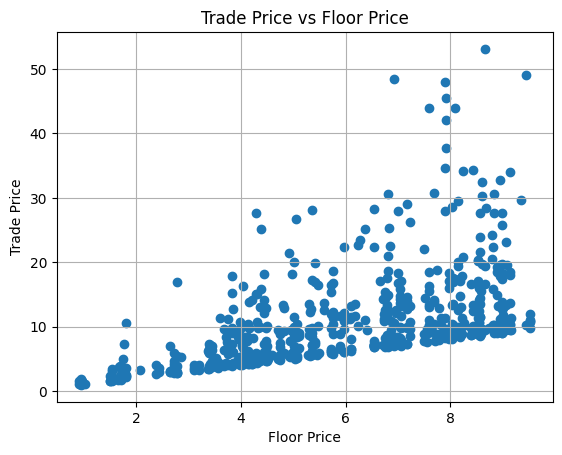

In [54]:
# only interested about nft not trading at the floor price (i.e. floor_price != trade_price)

sub = data[data['floor_price'] != data['trade_price']]

plt.scatter(sub['floor_price'], sub['trade_price'])
plt.xlabel('Floor Price')
plt.ylabel('Trade Price')
plt.title('Trade Price vs Floor Price')
plt.grid(True)
plt.show()

In [53]:
sub

,nft_id,trade_price,floor_price,Accessories_Background_freq,Accessories_Body_freq,Accessories_Eyes_freq,Accessories_Hat_freq,Accessories_Mouth_freq,Background_Body_freq,Background_Eyes_freq,Background_Hat_freq,Background_Mouth_freq,Body_Eyes_freq,Body_Hat_freq,Body_Mouth_freq,Eyes_Hat_freq,Eyes_Mouth_freq,Hat_Mouth_freq,Mouth_freq,Accessories_freq,Background_freq,Body_freq,Eyes_freq,Hat_freq,normalized_trade_price,Accessories_Bow Tie,Accessories_Cape,Accessories_Earrings,Accessories_Gold Chain,Accessories_Neck Tattoo,Accessories_Red Bandana,Accessories_Samurai Sword,Accessories_Scarf,Accessories_Sickle,Accessories_Tie,Accessories_Wings,Accessories_nan,Background_Forest Moss Green,Background_Lavender Dusk Purple,Background_Midnight Sapphire Blue,Background_Outer Space,"Background_Red, White, and Blue",Background_Rose Quartz Pink,Background_Seashell Pink,Background_Spiced Orange,Background_Stormcloud Grey,Background_Sunlit Gold,Body_Black,Body_Black - Overweight,Body_Blue,Body_Chocolate,Body_Cream,Body_Lilac,Body_Sable,Body_Tan,Body_Tan - Overweight,Body_White,Body_Zombie,Eyes_3-D Glasses,Eyes_Concerned,Eyes_Cyclop,Eyes_Drowsy,Eyes_Drowsy Cyclop,Eyes_Drowsy Laser Eyes,Eyes_Eye Patch,Eyes_Goggles,Eyes_Gold Shades,Eyes_Laser Eyes,Eyes_Normal,Eyes_Nouns Glasses,Eyes_Red Round Shades,Eyes_Red Shades,Eyes_VR Headset,Eyes_White Round Shades,Eyes_White Shades,Hat_Afro,Hat_Angel Halo,Hat_Baseball Cap,Hat_Beret,Hat_Bone,Hat_Cowboy,Hat_Cylinder,Hat_Devil Horns,Hat_Dreads,Hat_Elvis,Hat_Fire,Hat_Headband,Hat_Headphones,Hat_Leprechaun,Hat_Napoleon,Hat_No Hat,Hat_Party Hat,Hat_Pirate,Hat_Slickback,Hat_Sobrero,Hat_Top Hat,Hat_Wizard,Mouth_Bubble Gum,Mouth_Drooling,Mouth_Feral,Mouth_Happy,Mouth_Mustache,Mouth_Panting,Mouth_Sad,Mouth_Surprised,Mouth_Toothy,Mouth_Vampire
13,838,4.13,4.02,0.0193,0.0227,0.0187,0.0113,0.0353,0.0267,0.0260,0.0093,0.0400,0.0207,0.0120,0.0280,0.0087,0.0340,0.0113,0.2260,0.1393,0.1500,0.1553,0.1480,0.0447,1.027363,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
15,837,7.13,4.02,0.0673,0.0660,0.0047,0.1320,0.0967,0.0267,0.0013,0.0440,0.0400,0.0027,0.0480,0.0280,0.0033,0.0027,0.0707,0.2260,0.4247,0.1500,0.1553,0.0087,0.3147,1.773632,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
16,837,11.49,6.77,0.0673,0.0660,0.0047,0.1320,0.0967,0.0267,0.0013,0.0440,0.0400,0.0027,0.0480,0.0280,0.0033,0.0027,0.0707,0.2260,0.4247,0.1500,0.1553,0.0087,0.3147,1.697194,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
17,837,5.34,2.85,0.0673,0.0660,0.0047,0.1320,0.0967,0.0267,0.0013,0.0440,0.0400,0.0027,0.0480,0.0280,0.0033,0.0027,0.0707,0.2260,0.4247,0.1500,0.1553,0.0087,0.3147,1.873684,False,False,False,False,False,False,False,False,False,False,False,T

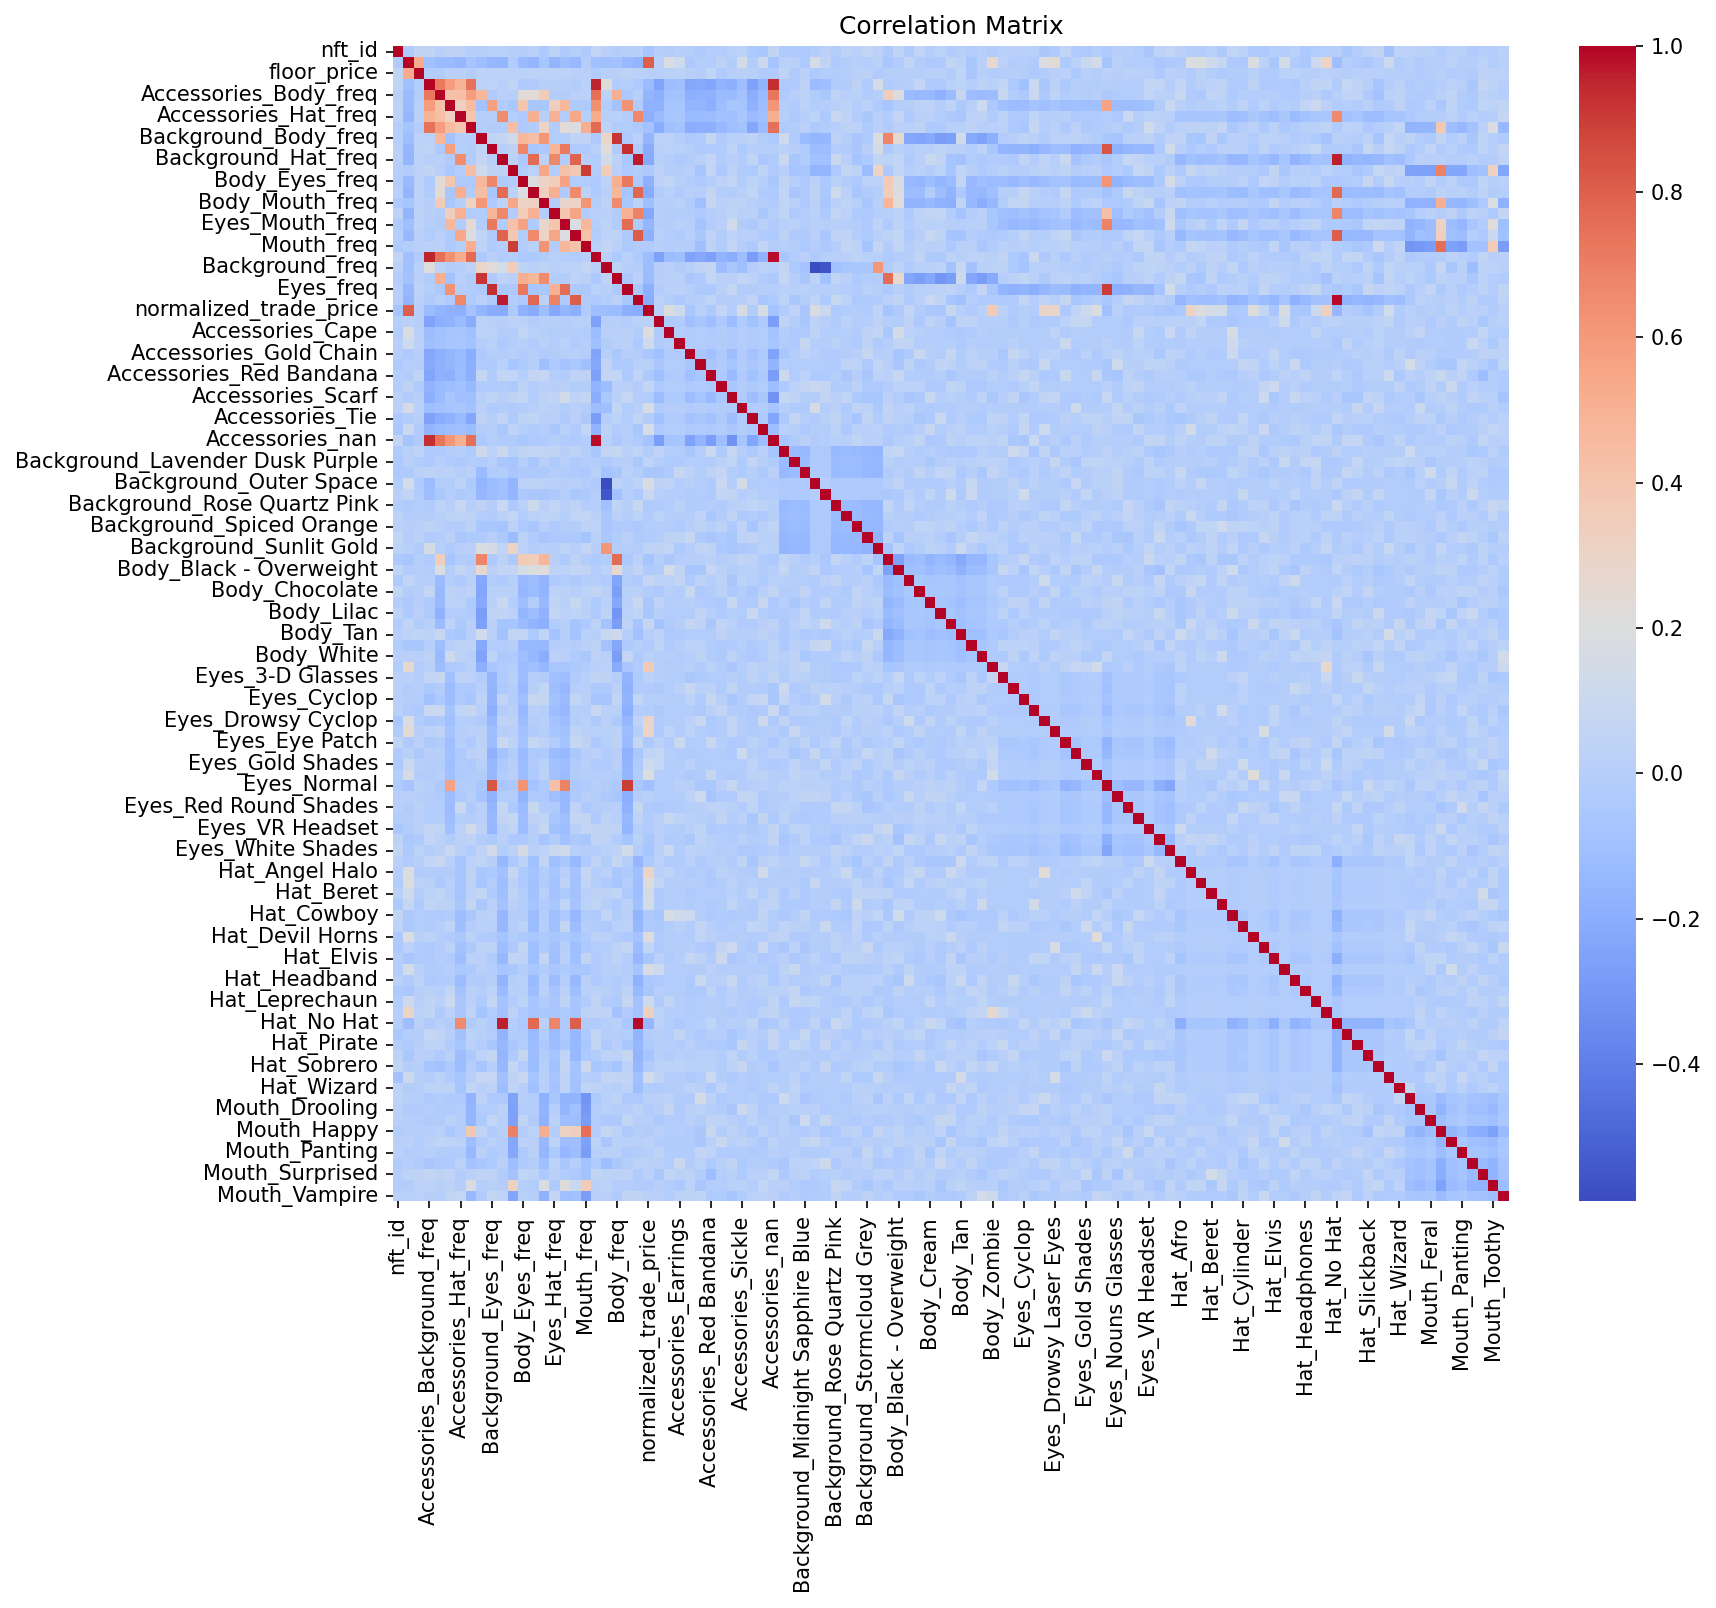

In [51]:
correl = data.corr()

plt.figure(figsize=(12, 10), dpi=150)
sns.heatmap(correl, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('img/correlation_matrix.png')
import autosklearn.regression

In [147]:
df.dtypes

nft_id                           int64
trade_price                    float64
floor_price                    float64
Accessories                     object
Background                      object
Body                            object
Eyes                            object
Hat                             object
Mouth                           object
Accessories_Background_freq    float64
Accessories_Body_freq          float64
Accessories_Eyes_freq          float64
Accessories_Hat_freq           float64
Accessories_Mouth_freq         float64
Background_Body_freq           float64
Background_Eyes_freq           float64
Background_Hat_freq            float64
Background_Mouth_freq          float64
Body_Eyes_freq                 float64
Body_Hat_freq                  float64
Body_Mouth_freq                float64
Eyes_Hat_freq                  float64
Eyes_Mouth_freq                float64
Hat_Mouth_freq                 float64
Mouth_freq                     float64
Accessories_freq         

## Catboost

In [148]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = df.drop(['nft_id', 'trade_price'], axis=1)
y = df['trade_price']

categorical_features = [col for col in X.columns if X[col].dtype == 'object']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(
    iterations=1000,            # Number of boosting iterations
    learning_rate=0.1,          # Learning rate
    depth=6,                    # Depth of the trees
    cat_features=categorical_features,  # Specify categorical features
    loss_function='RMSE',       # Loss function
    eval_metric='RMSE',         # Evaluation metric
    random_seed=42,
    verbose=200                 # Print logs every 200 iterations
)

train_pool = Pool(X_train, y_train, cat_features=categorical_features)
test_pool  = Pool(X_test, y_test, cat_features=categorical_features)

model.fit(train_pool, eval_set=test_pool)

y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Difference': y_test - y_pred,
    'Difference%': (y_test - y_pred) / y_test,
    'Difference**2': (y_test - y_pred) ** 2
})

print(f"MSE  = {results['Difference**2'].mean():.2f}")
print(f"RMSE = {np.sqrt(results['Difference**2'].mean()):.2f}")
print(f"MAE  = {results['Difference'].abs().mean():.2f}")
print(f"MAPE = {results['Difference%'].abs().mean():.2%}")

results

0:	learn: 4.8036122	test: 4.7048263	best: 4.7048263 (0)	total: 90.4ms	remaining: 1m 30s
200:	learn: 0.1217330	test: 0.6399725	best: 0.6399725 (200)	total: 6.16s	remaining: 24.5s
400:	learn: 0.0694057	test: 0.6319224	best: 0.6315390 (372)	total: 10.9s	remaining: 16.3s
600:	learn: 0.0493739	test: 0.6299670	best: 0.6299670 (600)	total: 16.1s	remaining: 10.7s
800:	learn: 0.0357345	test: 0.6289498	best: 0.6288278 (787)	total: 22.1s	remaining: 5.49s
999:	learn: 0.0277056	test: 0.6285403	best: 0.6284415 (880)	total: 26.9s	remaining: 0us

bestTest = 0.6284414966
bestIteration = 880

Shrink model to first 881 iterations.
MSE  = 0.39
RMSE = 0.63
MAE  = 0.14
MAPE = 1.27%
      Actual  Predicted  Difference  Difference%  Difference**2
1860    2.86   2.893537   -0.033537    -0.011726       0.001125
353     5.01   4.984929    0.025071     0.005004       0.000629
1333    8.39   8.362564    0.027436     0.003270       0.000753
905     6.85   6.825375    0.024625     0.003595       0.000606
1289    7.9

In [150]:
! pip install optuna

In [149]:
import optuna
from catboost import CatBoostRegressor, Pool

def objective(trial):
    iterations = trial.suggest_int('iterations', 100, 1000)
    learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.3)
    depth = trial.suggest_int('depth', 4, 12)
    
    model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        cat_features=categorical_features,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )
    
    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    test_pool = Pool(X_test, y_test, cat_features=categorical_features)
    
    model.fit(train_pool, eval_set=test_pool)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Number of trials

print("Best Parameters:", study.best_params)
print("Best MSE:", study.best_value)


ModuleNotFoundError: No module named 'optuna'

## Autosklearn

In [144]:
import autosklearn.regression

X = data.drop(['nft_id', 'trade_price'], axis=1)
y = data['trade_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


automodel = autosklearn.regression.AutoSklearnRegressor(
    time_left_for_this_task=3600,  # Total time for optimization in seconds
    per_run_time_limit=360,        # Time limit for each model in seconds
    n_jobs=-1,                     # Use all available cores
    seed=42
)

automodel.fit(X_train, y_train)

y_pred = automodel.predict(X)

y_pred = pd.DataFrame(y_pred, columns=['Predicted'], index=X.index)
y = pd.DataFrame(y)
y.columns = ['Actual']

results = y.reset_index().merge(y_pred.reset_index(), on='index')

results['Difference']  = results['Actual'] - results['Predicted']
results['Difference%'] = results['Difference'] / results['Actual']
results['Difference**2'] = results['Difference'] ** 2

print(f"MSE  = {results['Difference**2'].mean():.2f}")
print(f"RMSE = {np.sqrt(results['Difference**2'].mean()):.2f}")
print(f"MAE  = {results['Difference'].abs().mean():.2f}")
print(f"MAPE = {results['Difference%'].abs().mean():.2%}")

results


ImportError: cannot import name '_astype_copy_false' from 'sklearn.utils.fixes' (/spare/local/amorin/.conda/envs/ocean/lib/python3.8/site-packages/sklearn/utils/fixes.py)

<Axes: title={'center': 'Importance of Features to Trade Price'}>

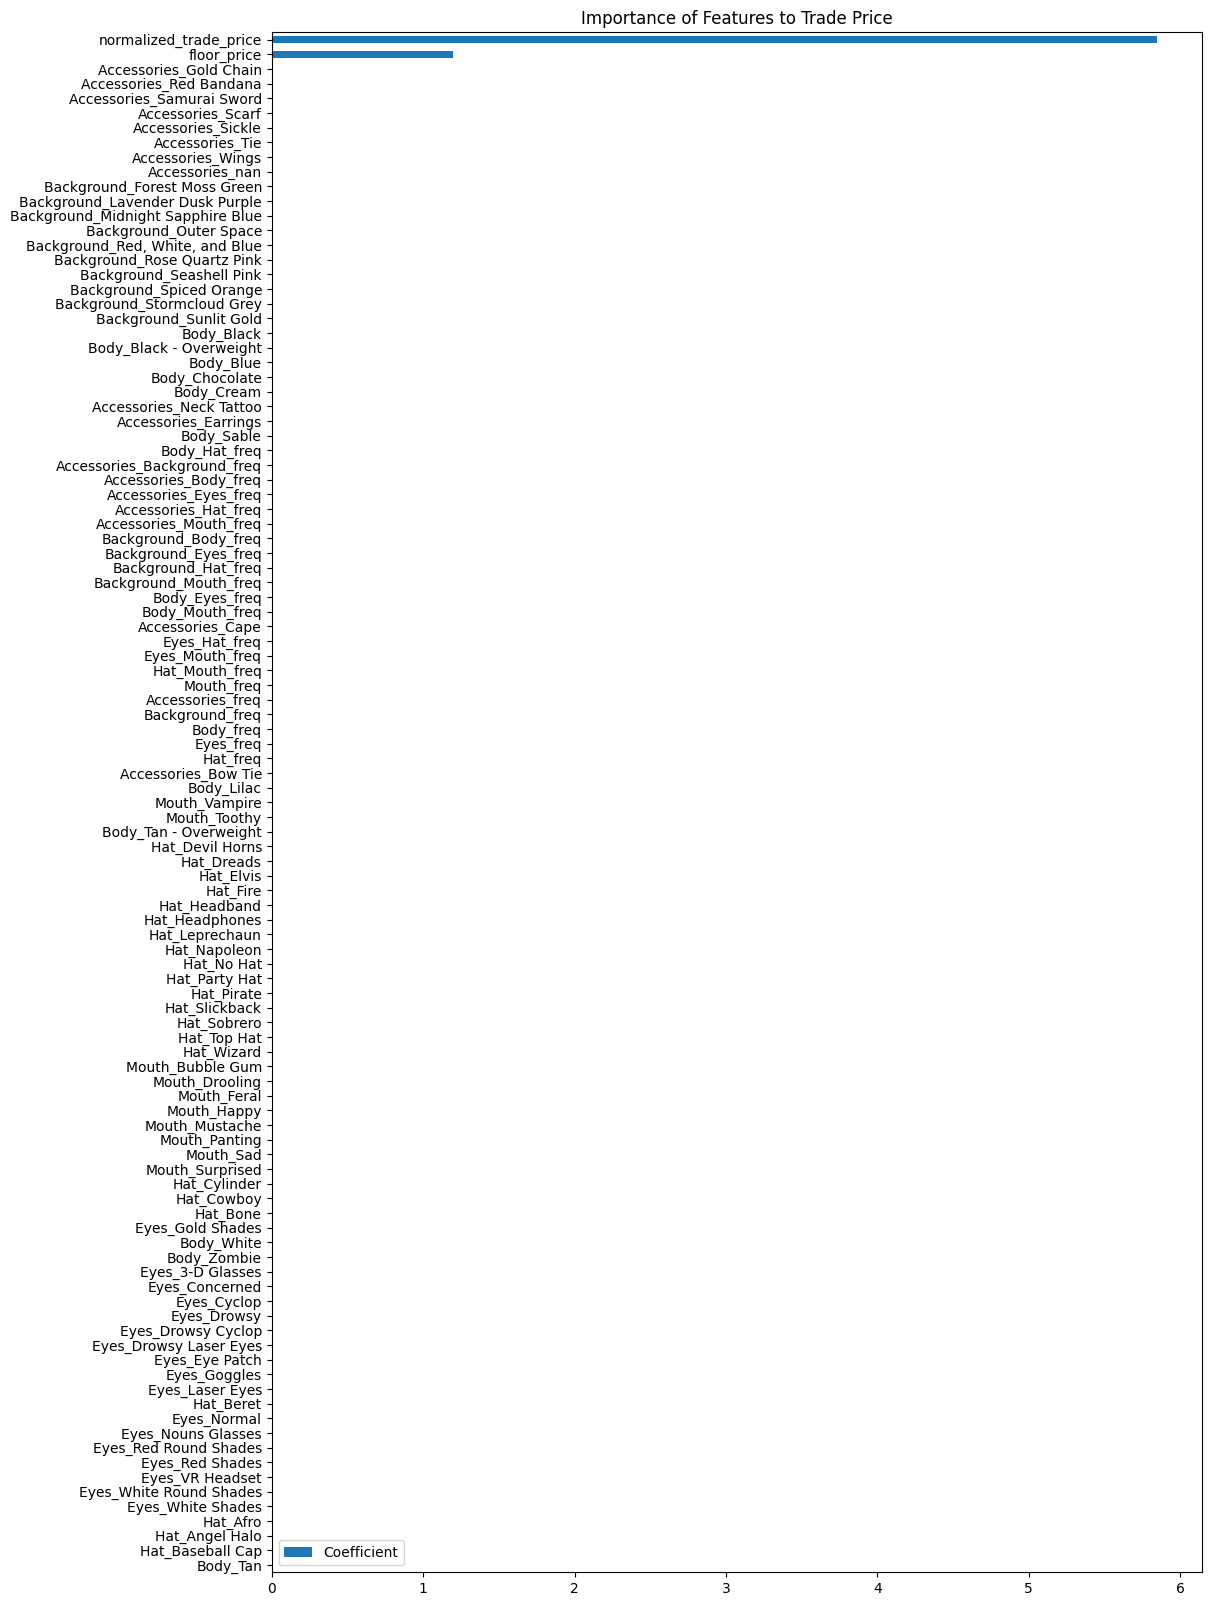

In [141]:
pd.DataFrame(best_model.coef_, index=X.columns, columns=['Coefficient']).sort_values(by='Coefficient', ascending=True).round(2).plot(kind='barh', figsize=(12, 20), title='Importance of Features to Trade Price')

In [135]:
from tpot import TPOTRegressor
from sklearn.model_selection import train_test_split

X = data.drop(['nft_id', 'trade_price'], axis=1)
y = data['trade_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tpot = TPOTRegressor(verbosity=2, generations=5, population_size=50, random_state=42)
tpot.fit(X_train, y_train)

y_pred = tpot.predict(X_test)
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Difference': y_test - y_pred,
    'Difference%': (y_test - y_pred) / y_test,
    'Difference**2': (y_test - y_pred) ** 2
})

print(f"MSE  = {results['Difference**2'].mean():.2f}")
print(f"RMSE = {np.sqrt(results['Difference**2'].mean()):.2f}")
print(f"MAE  = {results['Difference'].abs().mean():.2f}")
print(f"MAPE = {results['Difference%'].abs().mean():.2%}")

# Export the pipeline
tpot.export('best_pipeline.py')


Version 0.12.1 of tpot is outdated. Version 0.12.2 was released Friday February 23, 2024.


                                                                               
Generation 1 - Current best internal CV score: -0.8363415936729742
                                                                             
Generation 2 - Current best internal CV score: -0.8233268840451929
                                                                             
Generation 3 - Current best internal CV score: -0.7488422872559023
                                                                              
Generation 4 - Current best internal CV score: -0.7488422872559023
                                                                              
Generation 5 - Current best internal CV score: -0.7488422872559023
                                                                              
Best pipeline: DecisionTreeRegressor(DecisionTreeRegressor(input_matrix, max_depth=10, min_samples_leaf=17, min_samples_split=12), max_depth=10, min_samples_leaf=3, min_samples_split=4)
MSE  =

In [ ]:
y_pred = tpot.predict(X_test)

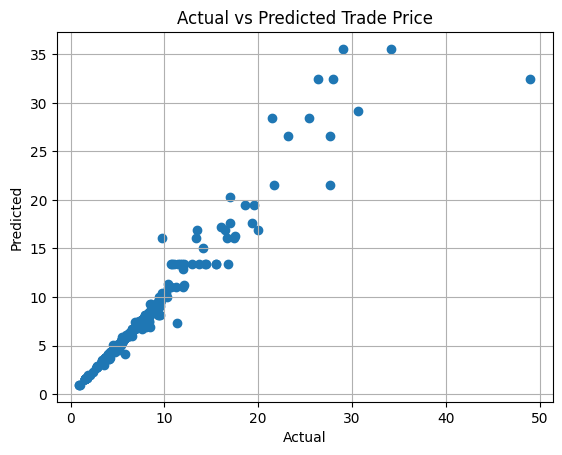

In [139]:
plt.scatter(results['Actual'], results['Predicted'])
plt.title('Actual vs Predicted Trade Price')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()